In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy
from scipy import stats
from matplotlib.markers import MarkerStyle
from iminuit import Minuit, cost
from scipy.stats import genextreme


colors = {
    'VWLS':      '#DC2626',
    'MLE':       '#2563EB',
    'PWM':       '#16A34A',
    'L-moments': '#D97706',
}

my_cmap = plt.colormaps["turbo"]
my_marker=MarkerStyle(marker="1", fillstyle='full', transform=None, capstyle=None, joinstyle=None)
plt.rcParams['font.family'] = 'serif'
plt.rcParams['savefig.dpi']=600
plt.rcParams["savefig.bbox"]='tight'
plt.rcParams["figure.figsize"]='6,3'
text_style = dict(horizontalalignment='right', verticalalignment='center',
                  fontsize=12, fontfamily='monospace')


save_figures = True

In [6]:
# Load Data
filename="gev-mu=70,alpha=10,gamma=0.3,N=e5.csv"
directory = "data"
directory_figures="../Figures"
filepath = directory+ "/" + filename
print(f"Filepath: {filepath}")
df   = pd.read_csv(filepath)

data = np.array(df.values[:,0])
data;

Filepath: data/gev-mu=70,alpha=10,gamma=0.3,N=e5.csv


In [26]:
subset_max = 10_000

filename0="mu=70,alpha=10,gamma=0"
data0 = scipy.stats.genextreme.rvs(c=0, loc=70, scale=10, size=subset_max, random_state=0)

filename1="mu=70,alpha=30,gamma=0"
data1 = scipy.stats.genextreme.rvs(c=0, loc=70, scale=30, size=subset_max, random_state=0)

filename2="mu=70,alpha=10,gamma=0.7"
data2 = scipy.stats.genextreme.rvs(c=-0.7, loc=70, scale=10, size=subset_max, random_state=0)

filename3="mu=70,alpha=10,gamma=-0.7"
data3 = scipy.stats.genextreme.rvs(c=0.7, loc=70, scale=10, size=subset_max, random_state=0)

filename4="mu=200,alpha=10,gamma=0"
data4 = scipy.stats.genextreme.rvs(c=0, loc=200, scale=10, size=subset_max, random_state=0)

min_value0 47.45280516416453 max_value0 177.22267693525075
min_value1 2.358415492493606 max_value1 391.6680308057522
min_value2 58.661782899409545 max_value2 26029.613136149892
min_value3 15.046756676841362 max_value3 84.27785710440207
min_value4 177.45280516416454 max_value4 307.2226769352508
79 2.358415492493606 400
plotting hist 0
plotting hist 1
plotting hist 2
plotting hist 3
plotting hist 4
save


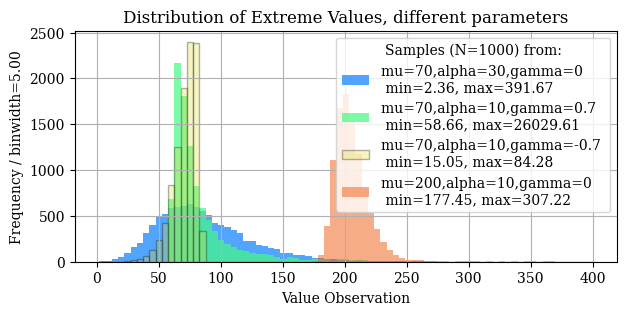

In [35]:

fig, ax_hist = plt.subplots(1, figsize=(7,3))


"""Histogram Plot"""
min_value0 = min(data0)
max_value0 = max(data0)

print("min_value0", min_value0, "max_value0", max_value0)

min_value1 = min(data1)
max_value1 = max(data1)

print("min_value1", min_value1, "max_value1", max_value1)

min_value2 = min(data2)
max_value2 = max(data2)

print("min_value2", min_value2, "max_value2", max_value2)

min_value3 = min(data3)
max_value3 = max(data3)

print("min_value3", min_value3, "max_value3", max_value3)

min_value4 = min(data4)
max_value4 = max(data4)

print("min_value4", min_value4, "max_value4", max_value4)

min_value = min(min_value0,min_value1,min_value2,min_value3,min_value4)
max_value = 400

#n_bins = 50
bin_width = 5
n_bins = int((max_value - min_value) / bin_width)
print(n_bins, min_value, max_value)


print("plotting hist 0")
#ax_hist.hist(data0, bins=n_bins, density=False, range=(min_value,round(max_value,-1)), alpha=0.5, color=my_cmap(0), label=f"{filename0} \n min={min_value0:.2f}, max={max_value0:.2f}")

print("plotting hist 1")
ax_hist.hist(data1, bins=n_bins, density=False, range=(min_value,round(max_value,-1)), alpha=0.9, color=my_cmap(0.2), label=f"{filename1} \n min={min_value1:.2f}, max={max_value1:.2f}")

print("plotting hist 2")
ax_hist.hist(data2, bins=n_bins, density=False, range=(min_value,round(max_value,-1)), alpha=0.7, color=my_cmap(0.4), label=f"{filename2} \n min={min_value2:.2f}, max={max_value2:.2f}")

print("plotting hist 3")
ax_hist.hist(data3, bins=n_bins, density=False, range=(min_value,round(max_value,-1)), alpha=0.3, color=my_cmap(0.6), edgecolor='black', label=f"{filename3} \n min={min_value3:.2f}, max={max_value3:.2f}")

print("plotting hist 4")
ax_hist.hist(data4, bins=n_bins, density=False, range=(min_value,round(max_value,-1)), alpha=0.5, color=my_cmap(0.8), label=f"{filename4} \n min={min_value4:.2f}, max={max_value4:.2f}")

#ax_hist.hist(data, bins=n_bins, density=False, range=(min_value,round(max_value,-1)), alpha=0.5, color=colors['VWLS'], label=f"Data from:\n{filename} \n min={min_value:.2f}, max={max_value:.2f}")
ax_hist.set_xlabel("Value Observation")
ax_hist.set_ylabel(f"Frequency / binwidth={bin_width:.2f}")
ax_hist.set_title("Distribution of Extreme Values, different parameters")
ax_hist.grid()
ax_hist.legend(title="Samples (N=1000) from:", loc="upper right")


if save_figures:
    print("save")
    fig.savefig(f"{directory_figures}/Hist_different_parameters.png")

save


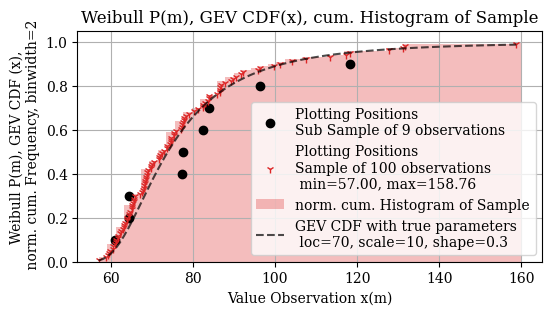

In [6]:

def weibull_plotting_positions(n):
    ranks = np.arange(1, n+1)
    P = ranks / (n + 1)
    return P

subdata=data[:100]
min_value = min(subdata)
max_value = max(subdata)
sorted_data = np.sort(subdata)
n = len(subdata)
ranks = np.arange(1, n + 1)
P = weibull_plotting_positions(n)

subsubdata=data[:9]
sorted_subsubdata = np.sort(subsubdata)
P_sub = weibull_plotting_positions(len(subsubdata))

fig, ax_p = plt.subplots(1, figsize=(6,3))
ax_p.plot(sorted_subsubdata, P_sub  , marker='o', linestyle='', color="black", label=f"Plotting Positions\nSub Sample of 9 observations")

ax_p.plot(sorted_data, P, marker=my_marker, linestyle='', color=colors['VWLS'], label=f"Plotting Positions\nSample of {n} observations\n min={min_value:.2f}, max={max_value:.2f}")
ax_p.hist(subdata, bins=50, density=True, range=(min_value,round(max_value,-1)), alpha=0.3, color=colors['VWLS'], label=f"norm. cum. Histogram of Sample", cumulative=True)

plot_data=np.linspace(min_value, max_value, 100)
cdf = genextreme.cdf(plot_data, c=-0.3, loc=70, scale=10)
ax_p.plot(plot_data, cdf, linestyle='--', alpha=0.7, color="black", label=f"GEV CDF with true parameters\n loc=70, scale=10, shape=0.3")

ax_p.set_ylabel("Weibull P(m), GEV CDF (x),\n norm. cum. Frequency, binwidth=2")
ax_p.set_xlabel("Value Observation x(m)")
ax_p.set_title("Weibull P(m), GEV CDF(x), cum. Histogram of Sample")
ax_p.grid()
ax_p.legend(loc="lower right")

if save_figures:
    print("save")
    fig.savefig(f"{directory_figures}/P,CDF,Hist_{filename}.png")

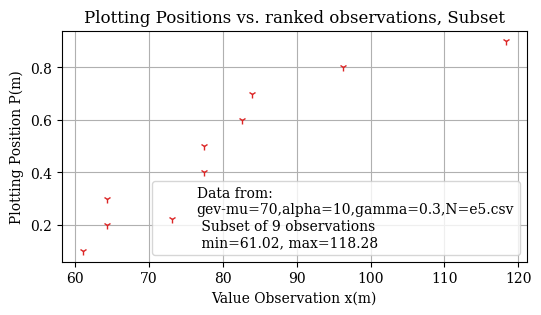

In [90]:
fig, ax = plt.subplots(1, 1, figsize=(6,3))

"""Plotting Positions Plot"""
subdata=data[:9]
min_value = min(subdata)
max_value = max(subdata)
sorted_data = np.sort(subdata)
n = len(subdata)
ranks = np.arange(1, n + 1)
P = weibull_plotting_positions(n)
cdf = genextreme.cdf(sorted_data, c=0.3, loc=70, scale=10)
ax.plot(sorted_data, P, marker=my_marker, linestyle='', color=colors['VWLS'], label=f"Data from:\n{filename}\n Subset of {n} observations\n min={min_value:.2f}, max={max_value:.2f}")
#ax.plot(P, cdf, linestyle='--', alpha=0.7, color="black", label=f"GEV CDF with true parameters\n loc=70, scale=10, shape=0.3")
ax.set_xlabel("Value Observation x(m)")
ax.set_ylabel("Plotting Position P(m)")
ax.set_title("Plotting Positions vs. ranked observations, Subset")
#ax_p.set_yscale('log')
ax.grid()
ax.legend(loc="lower right")

if save_figures:
    fig.savefig(f"{directory_figures}/P_{filename}.png")